In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "../data/raw/restaurant.csv"

df = pd.read_csv(DATA_PATH, sep = ";")

In [35]:
df.head()


,Unnamed: 0,DEMAND_DATE,Montag,Dienstag,Mittwoch,Donnerstag,Freitag,Samstag,Sonntag,MONTH_JAN,...,NIEDERSCHLAG_NO_DAYS_ABOVE_7D_MEAN,SONNE_NO_DAYS_ABOVE_7D_MEAN,LUFTTEMPERATUR_NO_DAYS_ABOVE_7D_MEAN,WIND_NO_DAYS_BELOW_7D_MEAN,BEWOELKUNG_NO_DAYS_BELOW_7D_MEAN,NIEDERSCHLAG_NO_DAYS_BELOW_7D_MEAN,SONNE_NO_DAYS_BELOW_7D_MEAN,LUFTTEMPERATUR_NO_DAYS_BELOW_7D_MEAN,ISHOLIDAY,WEEKEND
0,1,10.4.2013,0,0,0,0,1,0,0,0,...,0,3,3,4,4,0,4,4,0,0
1,2,10.5.2013,0,0,0,0,0,1,0,0,...,1,4,3,4,3,6,3,4,0,1
2,3,10.6.2013,0,0,0,0,0,0,1,0,...,1,4,3,4,3,6,3,4,0,1
3,4,10.7.2013,1,0,0,0,0,0,0,0,...,1,3,4,5,3,6,4,3,0,0
4,5,10.8.2013,0,1,0,0,0,0,0,0,...,1,3,5,5,3,6,4,2,0,0


In [36]:
df.shape

(760, 293)

In [37]:
df.columns.tolist()


['Unnamed: 0',
 'DEMAND_DATE',
 'Montag',
 'Dienstag',
 'Mittwoch',
 'Donnerstag',
 'Freitag',
 'Samstag',
 'Sonntag',
 'MONTH_JAN',
 'MONTH_FEB',
 'MONTH_MAR',
 'MONTH_APR',
 'MONTH_MAY',
 'MONTH_JUN',
 'MONTH_JUL',
 'MONTH_AUG',
 'MONTH_SEP',
 'MONTH_OCT',
 'MONTH_NOV',
 'MONTH_DEC',
 'YEAR_2013',
 'YEAR_2014',
 'YEAR_2015',
 'CALAMARI',
 'FISCH',
 'GARNELEN',
 'HAEHNCHEN',
 'KOEFTE',
 'LAMM',
 'STEAK',
 'TOTAL_FISCHPROD',
 'TOTAL_FLEISCH',
 'TOTAL',
 'CALAMARI_DEMAND_T1',
 'CALAMARI_DEMAND_T2',
 'CALAMARI_DEMAND_T3',
 'CALAMARI_DEMAND_T4',
 'CALAMARI_DEMAND_T5',
 'CALAMARI_DEMAND_T6',
 'CALAMARI_DEMAND_T7',
 'FISCH_DEMAND_T1',
 'FISCH_DEMAND_T2',
 'FISCH_DEMAND_T3',
 'FISCH_DEMAND_T4',
 'FISCH_DEMAND_T5',
 'FISCH_DEMAND_T6',
 'FISCH_DEMAND_T7',
 'GARNELEN_DEMAND_T1',
 'GARNELEN_DEMAND_T2',
 'GARNELEN_DEMAND_T3',
 'GARNELEN_DEMAND_T4',
 'GARNELEN_DEMAND_T5',
 'GARNELEN_DEMAND_T6',
 'GARNELEN_DEMAND_T7',
 'HAEHNCHEN_DEMAND_T1',
 'HAEHNCHEN_DEMAND_T2',
 'HAEHNCHEN_DEMAND_T3',
 'HAEHNCH

In [38]:
# exported index
df["Unnamed: 0"].head(10)

df = df.drop(columns = ["Unnamed: 0"])

In [39]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 760 entries, 0 to 759
Columns: 292 entries, DEMAND_DATE to WEEKEND
dtypes: float64(80), int64(211), str(1)
memory usage: 1.7 MB


In [40]:

df.describe(include = "all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
DEMAND_DATE,760,760,10.4.2013,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Montag,760.0,NaN,NaN,NaN,0.143421,0.350733,0.0,0.0,0.0,0.0,1.0
Dienstag,760.0,NaN,NaN,NaN,0.143421,0.350733,0.0,0.0,0.0,0.0,1.0
Mittwoch,760.0,NaN,NaN,NaN,0.139474,0.346668,0.0,0.0,0.0,0.0,1.0
Donnerstag,760.0,NaN,NaN,NaN,0.142105,0.349388,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
NIEDERSCHLAG_NO_DAYS_BELOW_7D_MEAN,760.0,NaN,NaN,NaN,5.478947,1.017413,0.0,5.0,6.0,6.0,7.0
SONNE_NO_DAYS_BELOW_7D_MEAN,760.0,NaN,NaN,NaN,3.719737,0.972144,0.0,3.0,4.0,4.0,6.0
LUFTTEMPERATUR_NO_DAYS_BELOW_7D_MEAN,760.0,NaN,NaN,NaN,3.565789,0.74451,1.0,3.0,4.0,4.0,6.0
ISHOLIDAY,760.0,NaN,NaN,NaN,0.028947,0.167769,0.0,0.0,0.0,0.0,1.0


In [41]:
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "unique": df.nunique()
})

summary.sort_values("missing_pct", ascending=False)

# yay no missing values

,dtype,missing,missing_pct,unique
DEMAND_DATE,str,0,0.0,760
Montag,int64,0,0.0,2
Dienstag,int64,0,0.0,2
Mittwoch,int64,0,0.0,2
Donnerstag,int64,0,0.0,2
...,...,...,...,...
NIEDERSCHLAG_NO_DAYS_BELOW_7D_MEAN,int64,0,0.0,6
SONNE_NO_DAYS_BELOW_7D_MEAN,int64,0,0.0,7
LUFTTEMPERATUR_NO_DAYS_BELOW_7D_MEAN,int64,0,0.0,6
ISHOLIDAY,int64,0,0.0,2


In [42]:
weekday_cols = [
    c for c in df.columns
    if c in ["Montag", "Dienstag", "Mittwoch",
        "Donnerstag", "Freitag", "Samstag", "Sonntag"
    ]
]

month_cols = [
    c for c in df.columns
    if c.startswith("MONTH_")
]

year_cols = [
    c for c in df.columns
    if c.startswith("YEAR_")
]

print("Weekday: ", len(weekday_cols)) #7 days
print("Month: ", len(month_cols)) # 12 months
print("Year: ", len(year_cols)) # 3 years


Weekday:  7
Month:  12
Year:  3


In [43]:
translations = {
    "Montag": "MONDAY",
    "Dienstag": "TUESDAY",
    "Mittwoch": "WEDNESDAY",
    "Donnerstag": "THURSDAY",
    "Freitag": "FRIDAY",
    "Samstag": "SATURDAY",
    "Sonntag": "SUNDAY",

    "FISCHPROD": "FISH_PRODUCTS",
    "FISCH": "FISH",
    "GARNELEN": "PRAWNS",
    "HAEHNCHEN": "CHICKEN",
    "KOEFTE": "KOFTA",
    "LAMM": "LAMB",
    "FLEISCH": "MEAT",

    "BEWOELKUNG": "CLOUD_COVER",
    "NIEDERSCHLAG": "PRECIPITATION",
    "SONNE": "SUNSHINE",
    "LUFTTEMPERATUR": "AIR_TEMPERATURE",
}

new_columns = []

for col in df.columns:
    new_col = col

    for german, english in translations.items():
        new_col = new_col.replace(german, english)

    new_columns.append(new_col)

df.columns = new_columns

In [44]:
df.columns.tolist()

['DEMAND_DATE',
 'MONDAY',
 'TUESDAY',
 'WEDNESDAY',
 'THURSDAY',
 'FRIDAY',
 'SATURDAY',
 'SUNDAY',
 'MONTH_JAN',
 'MONTH_FEB',
 'MONTH_MAR',
 'MONTH_APR',
 'MONTH_MAY',
 'MONTH_JUN',
 'MONTH_JUL',
 'MONTH_AUG',
 'MONTH_SEP',
 'MONTH_OCT',
 'MONTH_NOV',
 'MONTH_DEC',
 'YEAR_2013',
 'YEAR_2014',
 'YEAR_2015',
 'CALAMARI',
 'FISH',
 'PRAWNS',
 'CHICKEN',
 'KOFTA',
 'LAMB',
 'STEAK',
 'TOTAL_FISH_PRODUCTS',
 'TOTAL_MEAT',
 'TOTAL',
 'CALAMARI_DEMAND_T1',
 'CALAMARI_DEMAND_T2',
 'CALAMARI_DEMAND_T3',
 'CALAMARI_DEMAND_T4',
 'CALAMARI_DEMAND_T5',
 'CALAMARI_DEMAND_T6',
 'CALAMARI_DEMAND_T7',
 'FISH_DEMAND_T1',
 'FISH_DEMAND_T2',
 'FISH_DEMAND_T3',
 'FISH_DEMAND_T4',
 'FISH_DEMAND_T5',
 'FISH_DEMAND_T6',
 'FISH_DEMAND_T7',
 'PRAWNS_DEMAND_T1',
 'PRAWNS_DEMAND_T2',
 'PRAWNS_DEMAND_T3',
 'PRAWNS_DEMAND_T4',
 'PRAWNS_DEMAND_T5',
 'PRAWNS_DEMAND_T6',
 'PRAWNS_DEMAND_T7',
 'CHICKEN_DEMAND_T1',
 'CHICKEN_DEMAND_T2',
 'CHICKEN_DEMAND_T3',
 'CHICKEN_DEMAND_T4',
 'CHICKEN_DEMAND_T5',
 'CHICKEN_DEMAN

In [45]:
df["DEMAND_DATE"] = pd.to_datetime(df["DEMAND_DATE"])

df = (
    df.sort_values("DEMAND_DATE")
      .reset_index(drop=True)
)

print("Start:", df["DEMAND_DATE"].min())
print("End:", df["DEMAND_DATE"].max())
print("Rows:", len(df))
print("Duplicate dates:", df["DEMAND_DATE"].duplicated().sum())
print("Chronological:", df["DEMAND_DATE"].is_monotonic_increasing)

Start: 2013-10-04 00:00:00
End: 2015-11-07 00:00:00
Rows: 760
Duplicate dates: 0
Chronological: True


In [46]:
DISH_TARGETS = [
    "CALAMARI",
    "FISH",
    "PRAWNS",
    "CHICKEN",
    "KOFTA",
    "LAMB",
    "STEAK"
]

AGGREGATE_TARGETS = [
    "TOTAL_FISH_PRODUCTS",
    "TOTAL_MEAT",
    "TOTAL"
]

In [47]:
df[DISH_TARGETS].describe().T

,count,mean,std,min,25%,50%,75%,max
CALAMARI,760.0,4.252632,2.857045,0.0,2.0,4.0,6.00,25.0
FISH,760.0,4.686842,2.751325,0.0,3.0,4.0,6.00,17.0
PRAWNS,760.0,10.019737,4.616049,0.0,7.0,10.0,13.00,30.0
CHICKEN,760.0,30.396053,11.945958,0.0,22.0,29.0,36.25,93.0
KOFTA,760.0,22.089474,9.272902,2.0,16.0,21.0,27.00,71.0
LAMB,760.0,31.639474,12.654381,0.0,23.0,30.0,39.00,88.0
STEAK,760.0,22.480263,9.950980,1.0,16.0,21.0,27.00,82.0


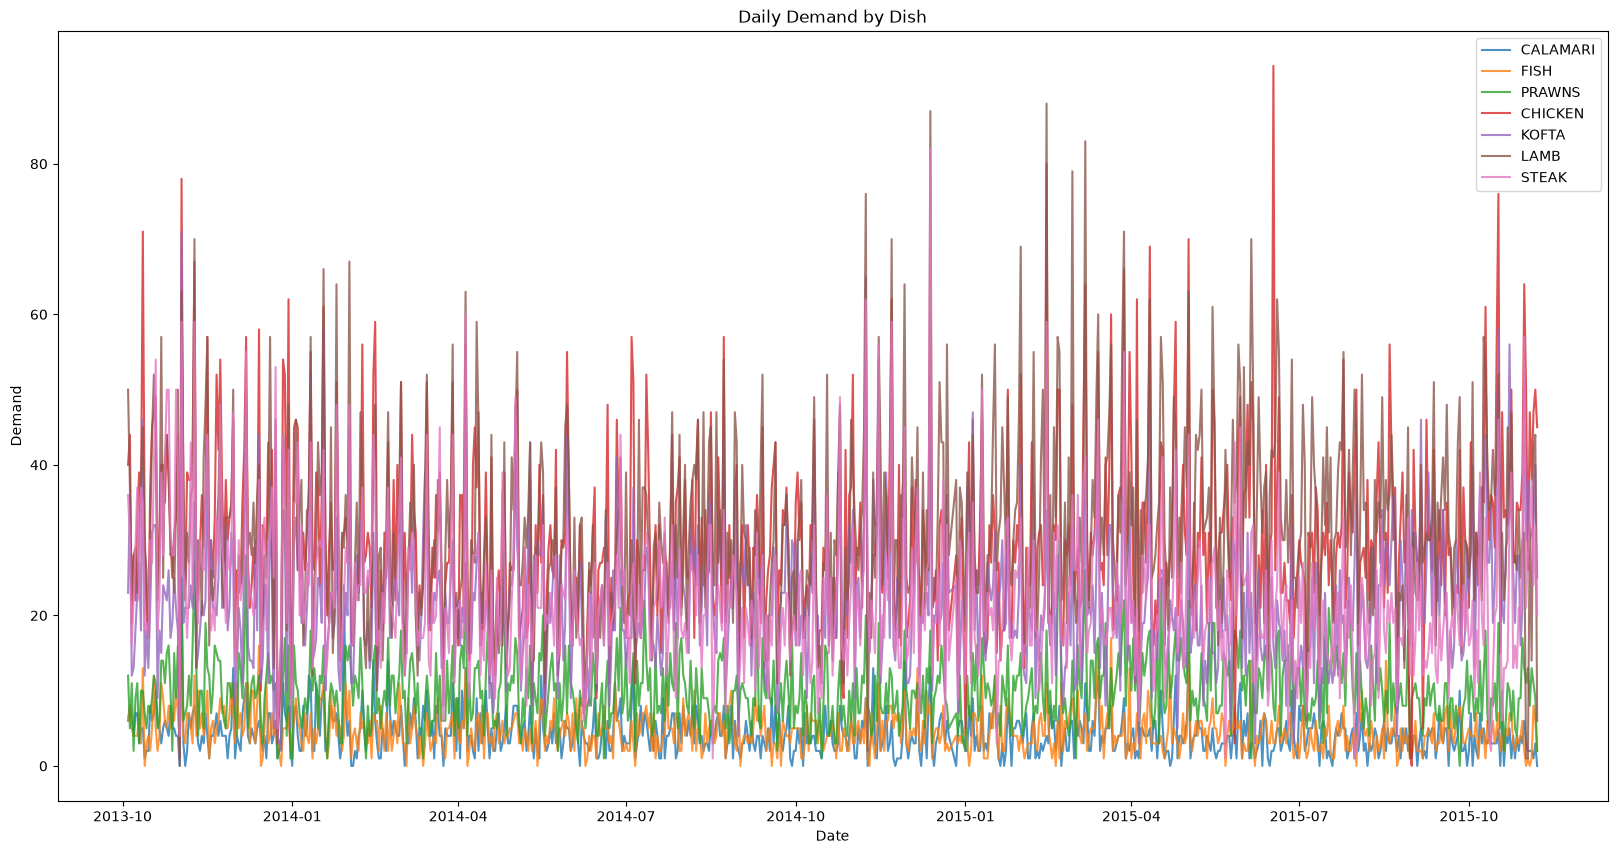

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

for dish in DISH_TARGETS:
    plt.plot(
        df["DEMAND_DATE"],
        df[dish],
        label=dish,
        alpha=0.8
    )

plt.xlabel("Date")
plt.ylabel("Demand")
plt.title("Daily Demand by Dish")
plt.legend()
plt.show()

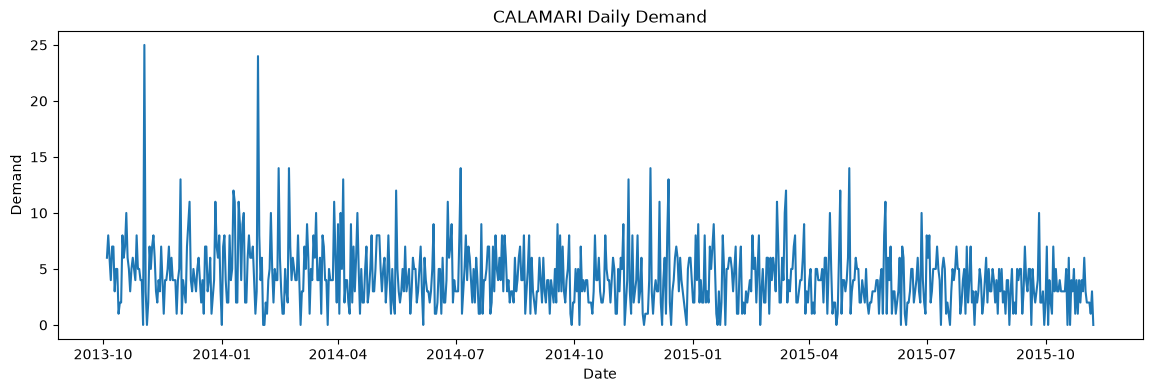

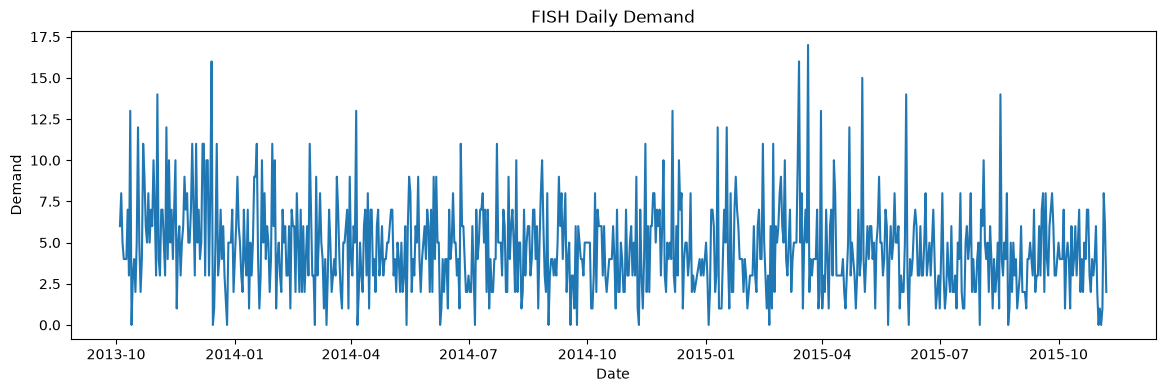

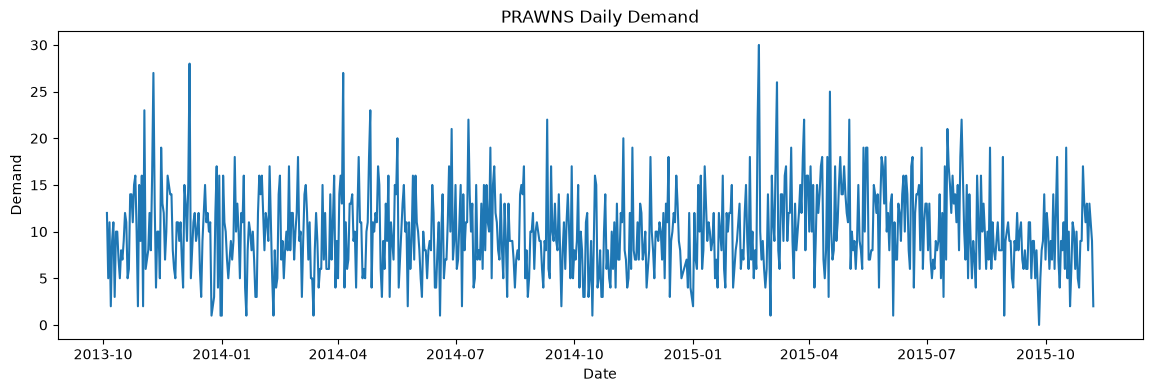

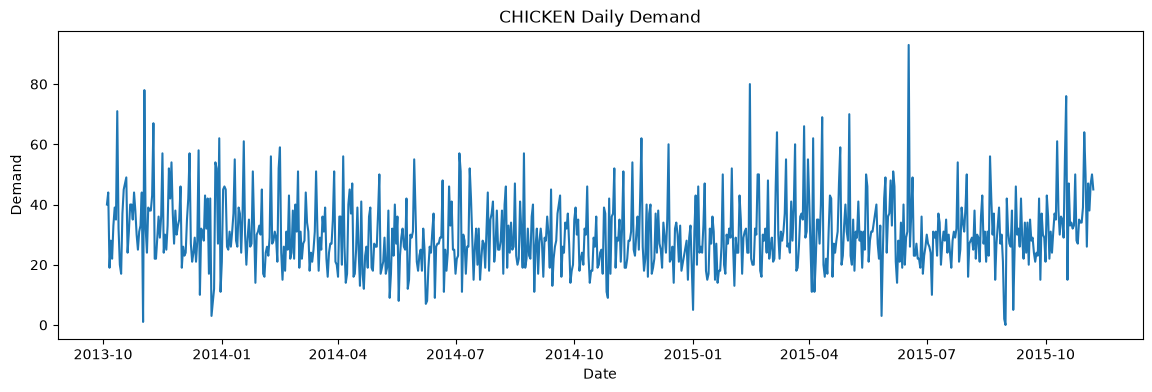

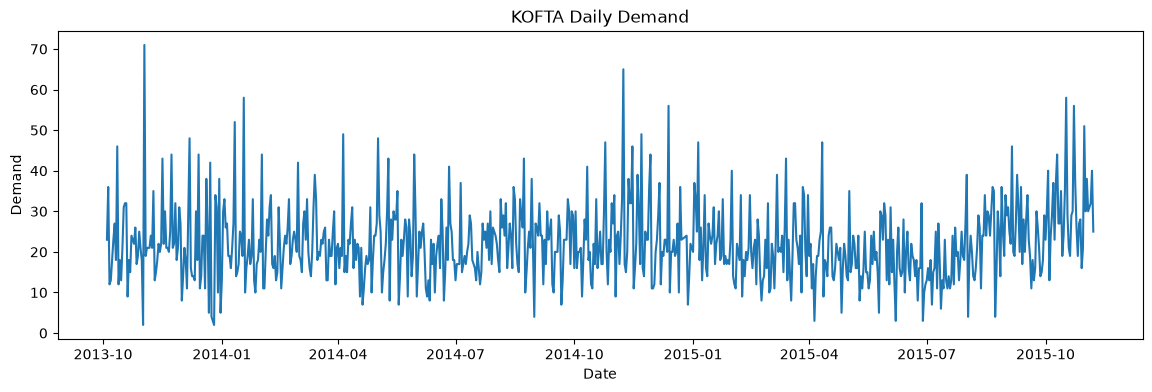

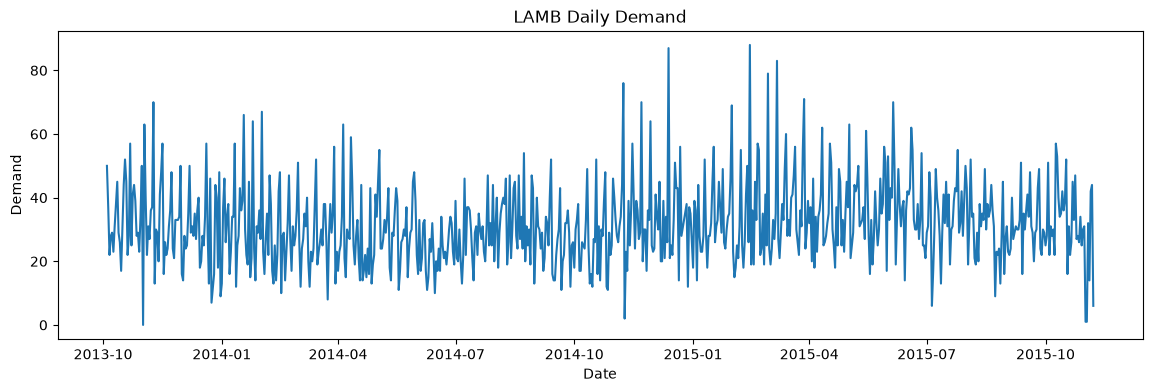

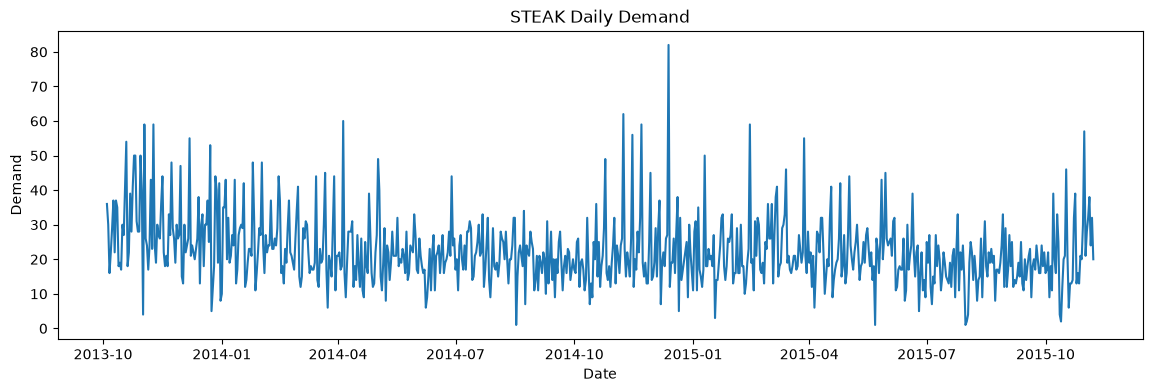

In [49]:
#cant really see, inspect by dish

for dish in DISH_TARGETS:
    plt.figure(figsize=(14, 4))

    plt.plot(df["DEMAND_DATE"], df[dish])

    plt.xlabel("Date")
    plt.ylabel("Demand")
    plt.title(f"{dish} Daily Demand")

    plt.show()

In [50]:
# high demand days?
for dish in DISH_TARGETS:
    print(f"\n{dish}")

    print(
        df[["DEMAND_DATE", dish]]
        .nlargest(5, dish)
    )


CALAMARI
    DEMAND_DATE  CALAMARI
29   2013-11-02        25
116  2014-01-29        24
132  2014-02-14        14
140  2014-02-22        14
273  2014-07-05        14

FISH
    DEMAND_DATE  FISH
528  2015-03-21    17
71   2013-12-14    16
521  2015-03-14    16
570  2015-05-02    15
29   2013-11-02    14

PRAWNS
    DEMAND_DATE  PRAWNS
500  2015-02-21      30
64   2013-12-07      28
36   2013-11-09      27
182  2014-04-05      27
514  2015-03-07      26

CHICKEN
    DEMAND_DATE  CHICKEN
616  2015-06-17       93
493  2015-02-14       80
29   2013-11-02       78
738  2015-10-17       76
8    2013-10-12       71

KOFTA
    DEMAND_DATE  KOFTA
29   2013-11-02     71
399  2014-11-08     65
105  2014-01-18     58
738  2015-10-17     58
434  2014-12-13     56

LAMB
    DEMAND_DATE  LAMB
493  2015-02-14    88
434  2014-12-13    87
514  2015-03-07    83
507  2015-02-28    79
399  2014-11-08    76

STEAK
    DEMAND_DATE  STEAK
434  2014-12-13     82
399  2014-11-08     62
182  2014-04-05     60
29 

In [51]:
avg_demand = (
    df[DISH_TARGETS]
    .mean()
    .sort_values(ascending=False)
)

avg_demand

LAMB        31.639474
CHICKEN     30.396053
STEAK       22.480263
KOFTA       22.089474
PRAWNS      10.019737
FISH         4.686842
CALAMARI     4.252632
dtype: float64

In [52]:
# weekly seasonality
df["DAY_OF_WEEK"] = df["DEMAND_DATE"].dt.day_name()

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_demand = (
    df.groupby("DAY_OF_WEEK")[DISH_TARGETS]
      .mean()
      .reindex(weekday_order)
)

weekday_demand

/tmp/ipykernel_2034/752288188.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["DAY_OF_WEEK"] = df["DEMAND_DATE"].dt.day_name()


,CALAMARI,FISH,PRAWNS,CHICKEN,KOFTA,LAMB,STEAK
DAY_OF_WEEK,,,,,,,
Monday,3.036697,3.990826,8.633028,24.036697,18.788991,25.119266,18.220183
Tuesday,3.715596,4.192661,8.788991,27.660550,20.412844,28.394495,19.761468
Wednesday,4.433962,4.990566,10.245283,30.188679,21.547170,29.915094,21.886792
Thursday,3.861111,4.342593,9.796296,29.351852,21.685185,31.435185,20.944444
Friday,5.119266,5.596330,11.596330,33.816514,25.100917,37.532110,25.091743
Saturday,6.672727,6.390909,14.045455,46.554545,32.863636,47.645455,35.200000
Sunday,2.908257,3.293578,7.000000,21.000000,14.110092,21.238532,16.110092


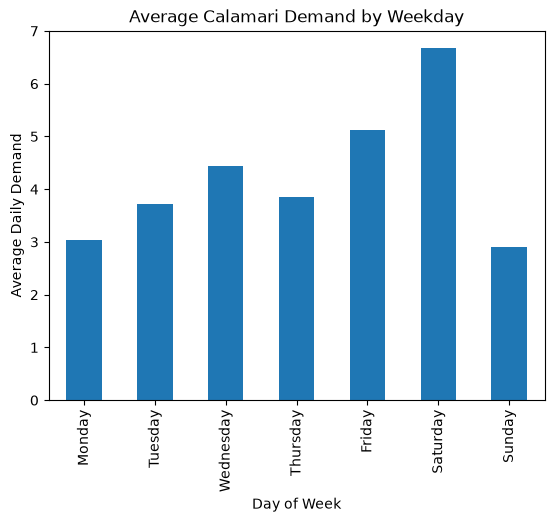

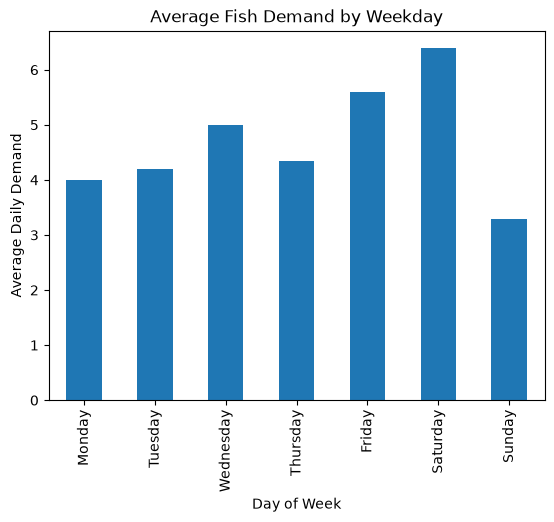

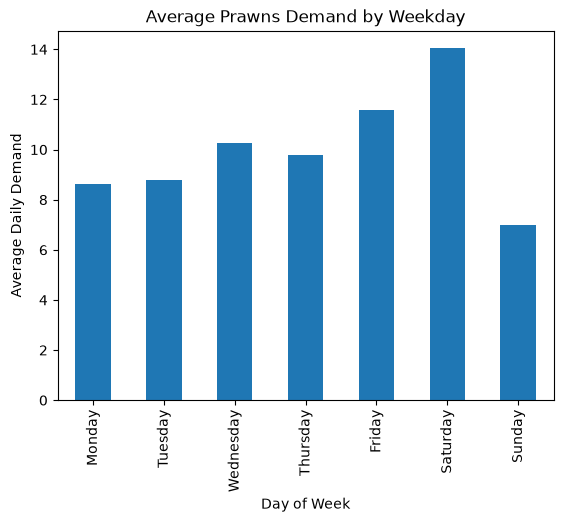

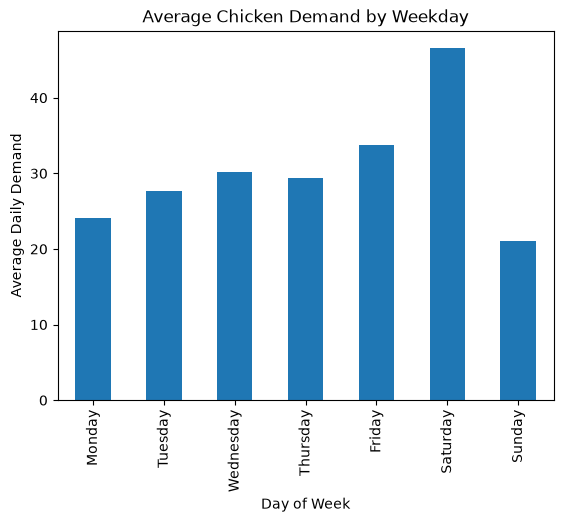

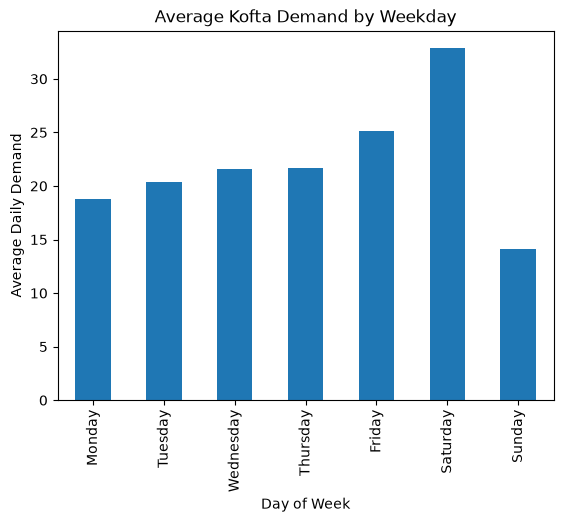

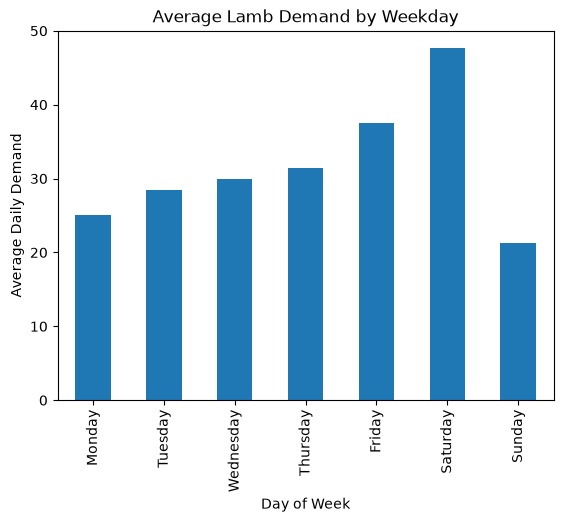

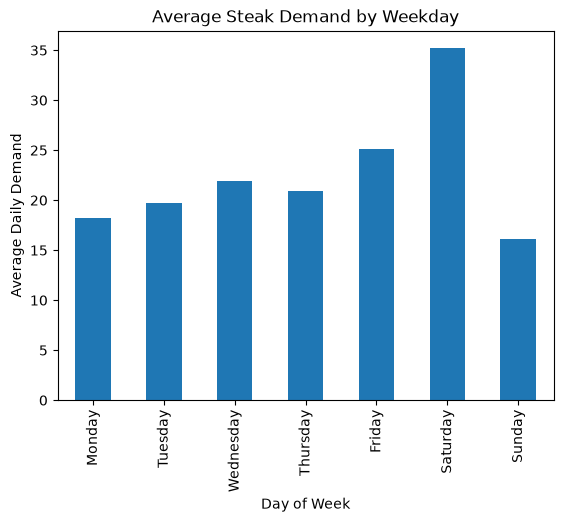

In [53]:
#they like saturdays, not so much sundays
for dish in DISH_TARGETS:
    (
        weekday_demand[dish]
        .reindex(weekday_order)
        .plot(kind="bar")
    )

    plt.ylabel("Average Daily Demand")
    plt.xlabel("Day of Week")
    plt.title(f"Average {dish.title()} Demand by Weekday")

    plt.show()

In [54]:
#monthly seasonalities?
df["MONTH"] = df["DEMAND_DATE"].dt.month

monthly_demand = (
    df.groupby("MONTH")[DISH_TARGETS]
      .mean()
)

monthly_demand

/tmp/ipykernel_2034/3474066087.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["MONTH"] = df["DEMAND_DATE"].dt.month


,CALAMARI,FISH,PRAWNS,CHICKEN,KOFTA,LAMB,STEAK
MONTH,,,,,,,
1,5.161290,5.000000,9.483871,30.274194,23.209677,32.887097,23.629032
2,4.160714,4.589286,9.821429,30.232143,20.446429,31.678571,23.767857
3,4.870968,5.064516,10.741935,31.790323,22.354839,32.709677,23.790323
4,4.316667,4.350000,11.766667,29.566667,19.283333,30.733333,21.050000
5,4.241935,4.854839,11.048387,29.403226,21.693548,33.516129,23.096774
6,3.783333,4.316667,10.133333,28.466667,18.366667,30.633333,19.900000
7,4.274194,4.016129,11.241935,28.967742,18.516129,31.370968,19.580645
8,3.919355,4.596774,9.322581,28.951613,23.596774,31.580645,19.564516
9,3.516667,4.200000,8.716667,28.166667,23.400000,29.300000,18.233333


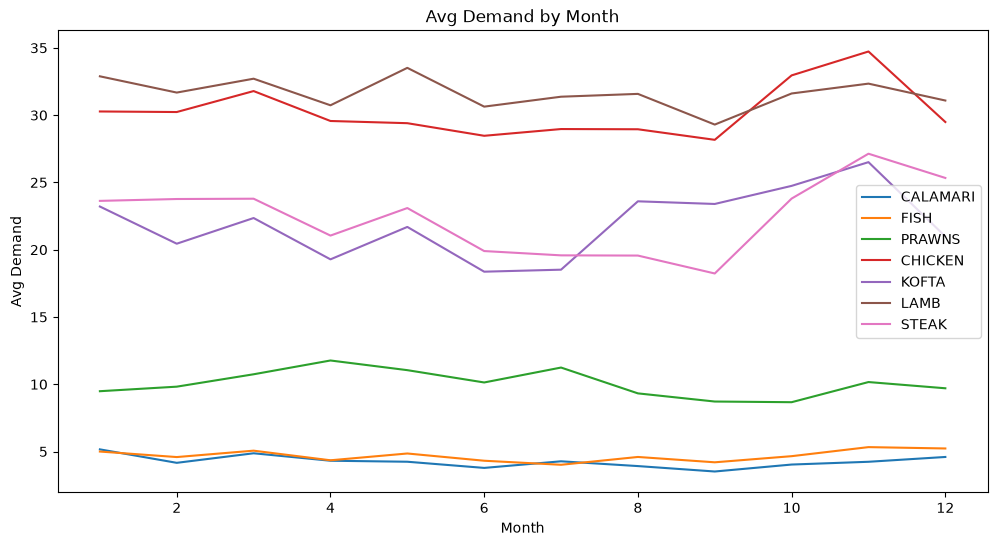

In [55]:
#end of year festivities yay
monthly_demand.plot(figsize=(12, 6))

plt.xlabel("Month")
plt.ylabel("Avg Demand")
plt.title("Avg Demand by Month")
plt.show()

In [ ]:
# looks good n normal -> english clean csv yay
df.to_csv("../data/interim/restaurant_clean.csv", index = False)